# Query

The `query` module can be used to subset the data objects based on the Sample IDs or other metadata. This can be usefull in statistical analysis, containment queries and visualisation.

We use the `objects_to_plot` parameter in the `visualise` method to see the result of our query.

A query-like object is anything that MuSpAn can ultimately interpret as a list of Object IDs. For completeness, the query-like things that MuSpAn recognises are:

- Queries
- Query containers - these massively boost the power of queries to ask complex questions
- Tuples of the following forms:
    - `(label_name, label_value)` - interpreted as `ms.query.query(domain, ('label',label_name),'is',label_value)`
    - `('collection', collection_name)` - interpreted as `ms.query.query(domain, ('collection',),'is',collection_name)`
    - `('object', object_type)` - interpreted as `ms.query.query(domain, ('object','type'),'is',object_type)`
    - `('label', label_name)` - interpreted as `ms.query.query(domain, ('label',label_name),'is',True)`, i.e., the object has this label

Additionally, lists of integers are not query-like, but will be interpreted directly as a list of object IDs in most places that accept queries.

MuSpAn domain loaded successfully. Domain summary:
Domain name: Xenium-Healthy-Colon
Number of objects: 74174
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript', 'Transcript ID'] 
Networks: [] 
Distance matrices: []


(<Figure size 1000x600 with 2 Axes>, <Axes: >)

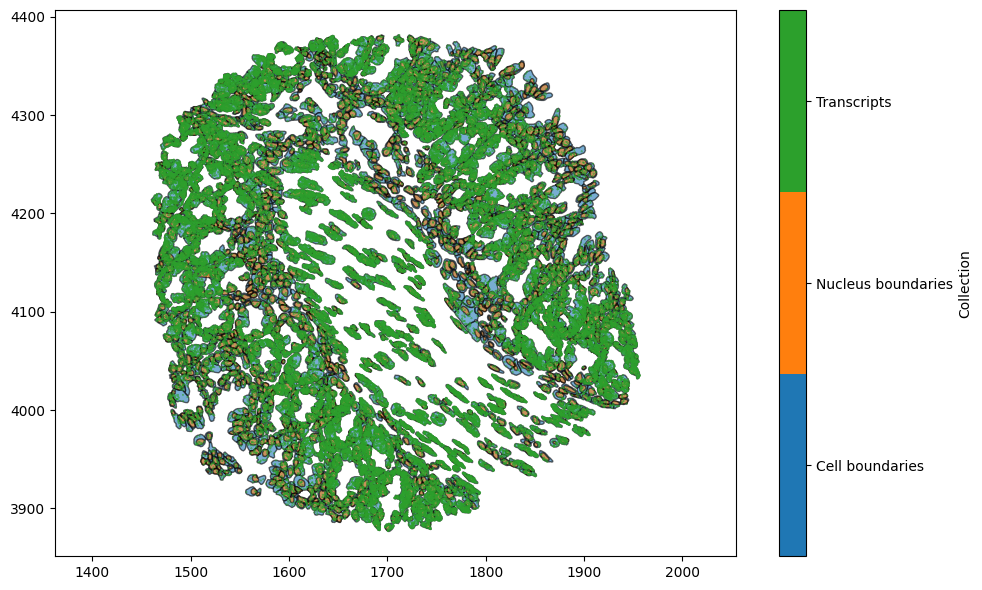

In [2]:
# Import necessary libraries
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np

# Load the example domain 'Xenium-Healthy-Colon'
domain = ms.datasets.load_example_domain('Xenium-Healthy-Colon')

# Create a figure with a specified size
plt.figure(figsize=(10, 6))

# Visualise the domain with a specified marker size
ms.visualise.visualise(domain, ax=plt.gca(), marker_size=0.1)

First, we will visualise objects based on their Sample IDs.

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

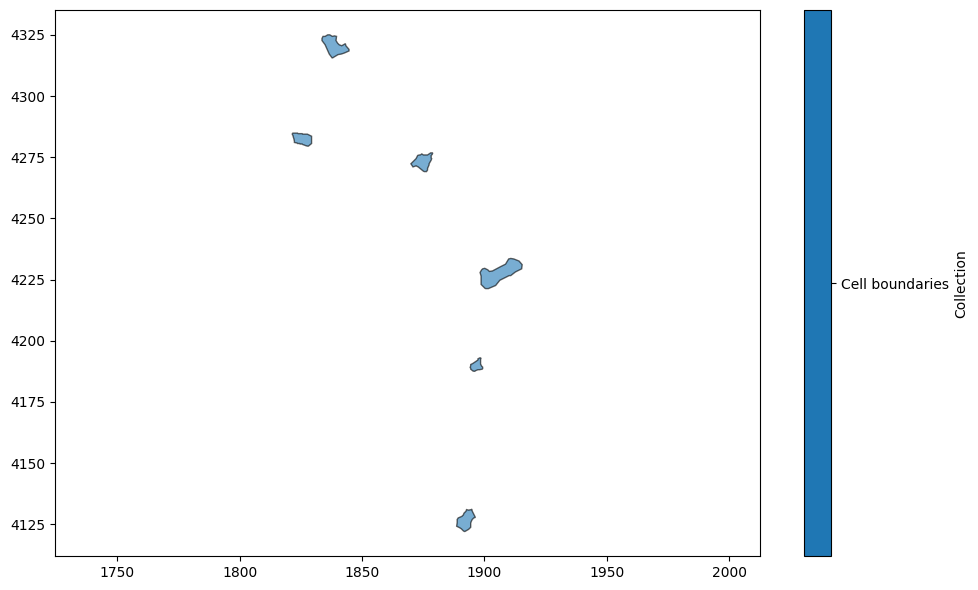

In [3]:
# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Visualise the domain, plotting only specific objects with given IDs
ms.visualise.visualise(domain, ax=plt.gca(), objects_to_plot=[0, 12, 32, 46, 111, 128])

Behind the curtain, it will always use Sample IDs. However we can pass a query tuple which MuSpan will convert to the Sample IDs.

### Query Tuple Syntax

- (**From what source**, **What value** )

So if we wanted to plot the "Cell boundaries" in the "Collections" slot:

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

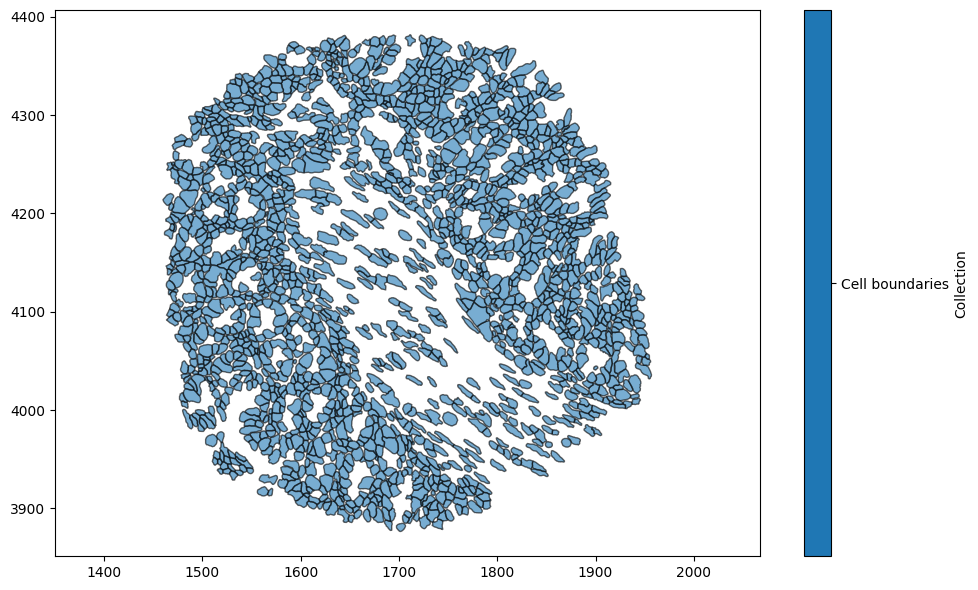

In [4]:
# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Visualise the domain, plotting only objects that are in the 'Cell boundaries' collection
ms.visualise.visualise(domain, ax=plt.gca(), objects_to_plot=('Collection', 'Cell boundaries'))

To visualise objects belonging to "Cluster 2" of the "Cluster ID" metadata:

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

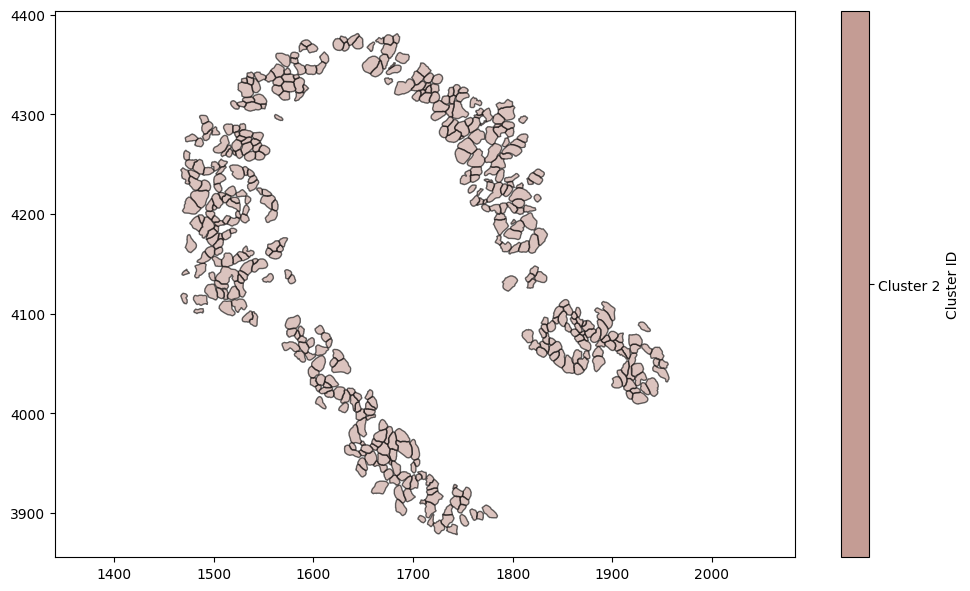

In [5]:
# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Visualise the domain, plotting only objects with 'Cluster ID' equal to 'Cluster 2'
# and color the objects by their 'Cluster ID'
ms.visualise.visualise(
    domain,
    ax=plt.gca(),
    objects_to_plot=('Cluster ID', 'Cluster 2'),
    color_by='Cluster ID'
)

## Making more complex query

Rather than just use a setting a query in `visualise` we can build a query using the `query` NameSpace and the `query` function. This can then be passed to `visualise`.

The syntax from the query above is `ms.query.query(domain, ('label', 'Cluster ID'), 'is', 'Cluster 2')`. 

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

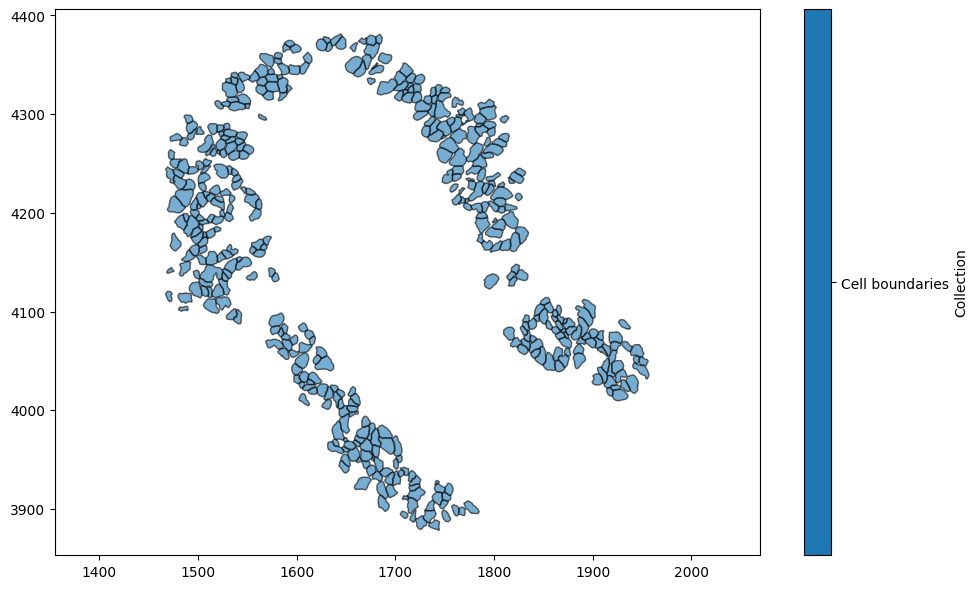

In [6]:
# Create a query to select objects where the label 'Cluster ID' is 'Cluster 2'
query_cluster2 = ms.query.query(domain, ('label', 'Cluster ID'), 'is', 'Cluster 2')

# Create a new figure for plotting
plt.figure(figsize=(10, 6))

# Visualise the domain with objects matching the query
ms.visualise.visualise(domain, ax=plt.gca(), objects_to_plot=query_cluster2)

# Combining queries - query containers

We can build more complex queries by combining them with **'AND', 'OR', 'AND NOT'** conditionals. 

Let’s suppose we’ve identified a particular cell of interest (e.g., by exploring the data in Xenium explorer), with the ID ‘dfbfdjho-1’, and we want to plot the location of all ‘Sox9’ transcripts within the boundary of this cell.

The Boolean statements we’re going to need here are:
- A: The label ‘Cell ID’ is ‘dfbfdjho-1’
- B: Collection is ‘Cell boundaries’
- C: Collection is ‘Transcripts’
- D: The label ‘Transcript ID’ is ‘Sox9’

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

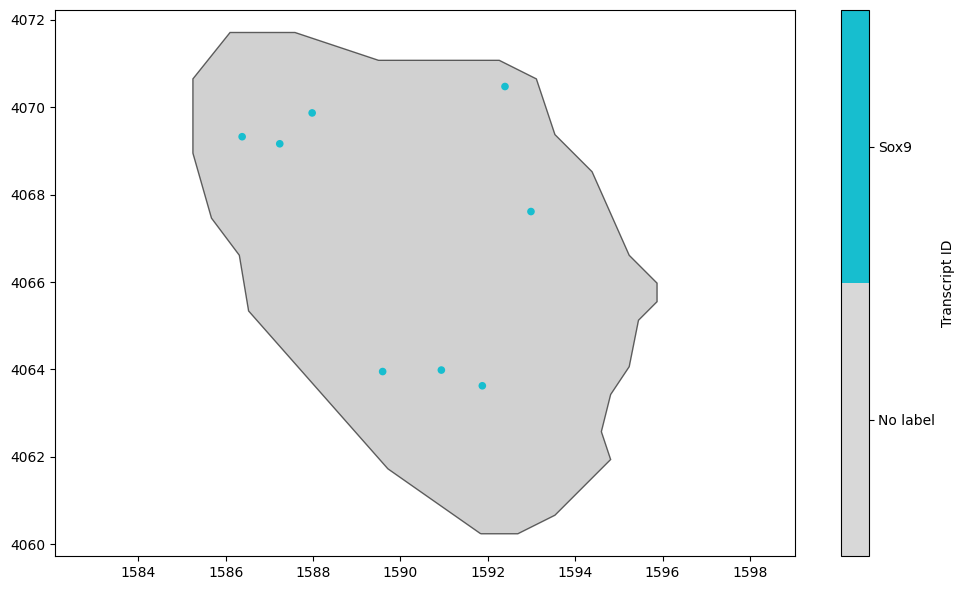

In [7]:
# Define the queries for each condition

# Query A: The label 'Cell ID' is 'dfbfdjho-1'
query_A = ms.query.query(domain, ('label', 'Cell ID'), 'is', 'dfbfdjho-1')

# Query B: Collection is 'Cell boundaries'
query_B = ms.query.query(domain, ('collection',), 'is', 'Cell boundaries')

# Query C: Collection is 'Transcripts'
query_C = ms.query.query(domain, ('collection',), 'is', 'Transcripts')

# Query D: The label 'Transcript ID' is 'Sox9'
query_D = ms.query.query(domain, ('label', 'Transcript ID'), 'is', 'Sox9')

# Then we can start combining the queries.
query_C_and_D = ms.query.query_container(query_C, 'AND', query_D)
query_B_or_CandD = ms.query.query_container(query_B, 'OR', query_C_and_D)
final_query = ms.query.query_container(query_A, 'AND', query_B_or_CandD)

# Create a new figure with specified size
plt.figure(figsize=(10, 6))

# Visualize the final query results, coloring objects by 'Transcript ID'
ms.visualise.visualise(domain, ax=plt.gca(), objects_to_plot=final_query, color_by='Transcript ID')

## Containment queries

A common problem you may encounter in spatial analysis is finding out what objects (e.g., in spatial biology, transcripts, nuclei, cells, region annotations etc) are contained in other objects (e.g., in spatial biology, cells, pathology annotations etc).

The dataset "Macrophage-Hypoxia-ROI" is composed of point-like Macrophages and shapes defining epithelial regions and hypoxia levels within them. 

We’ll design a query that idenifies which macrophages are within a epithelial region (PanCK shapes). To do this, we’ll need to set the ‘property’ parameter in a query to ‘contains’. In particular, a general query is of the form:

`some_query = ms.query.query(domain, property, relation, comparison_value)`

Here, we want to set `property = (‘contains’, (contained_objects, containing_objects))` where containing_objects are the shapes we are wanting to query inside of, and contained_objects are the set of objects that were are filtering.

MuSpAn domain loaded successfully. Domain summary:
Domain name: Example ROI from Pugh/Macklin H&N cancer hypoxia data
Number of objects: 1163
Collections: ['Macrophages', 'Pimo', 'PanCK', 'CAIX', 'Simplified boundaries']
Labels: [] 
Networks: [] 
Distance matrices: []


Text(0.5, 1.0, 'Macrophages outside Tumour')

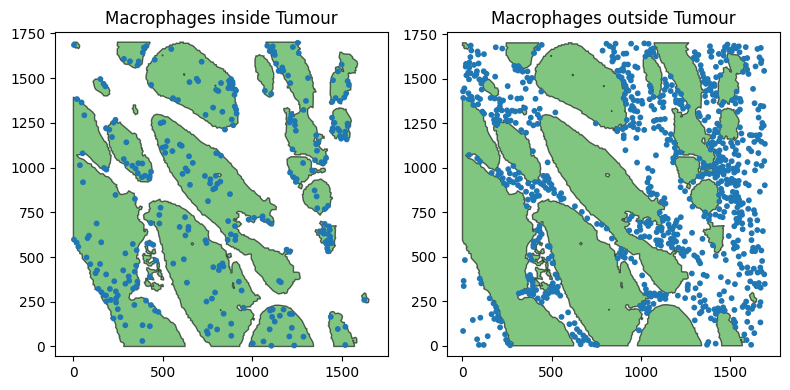

In [8]:
# Load in the example domain
example_domain = ms.datasets.load_example_domain('Macrophage-Hypoxia-ROI')

# creating queries for the objects of interest
query_macrophage = ms.query.query(example_domain, ('collection',),'is', 'Macrophages')
query_tumour = ms.query.query(example_domain, ('collection',),'is', 'PanCK')

# query which macrophages are in the tumour
query_mac_in_tumour = ms.query.query(example_domain,('contains',(query_macrophage,  query_tumour )), 'is', True)

# query which macrophages are outside the tumour
query_mac_outside_tumour = ms.query.query(example_domain,('contains',(query_macrophage,  query_tumour )), 'is', False)

# plot the tumour and filtered macrophages together
fig,ax=plt.subplots(1,2, figsize=(8,4))
ms.visualise.visualise(example_domain,objects_to_plot=query_mac_in_tumour,marker_size=10,ax=ax[0],add_cbar=False)
ms.visualise.visualise(example_domain,objects_to_plot=query_tumour,ax=ax[0],add_cbar=False)
ax[0].set_title('Macrophages inside Tumour')

ms.visualise.visualise(example_domain,objects_to_plot=query_mac_outside_tumour,marker_size=10,ax=ax[1],add_cbar=False)
ms.visualise.visualise(example_domain,objects_to_plot=query_tumour,ax=ax[1],add_cbar=False)
ax[1].set_title('Macrophages outside Tumour')

We could have used the following shorthand to perform the same operation:

`query_mac_in_tumour_shorthand = ms.query.query(example_domain,('contains',( ('collection','Macrophages'),('collection','PanCK') )),'is', True)`

Lets ask if the CAIX regions are fully contained with Pimo.

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

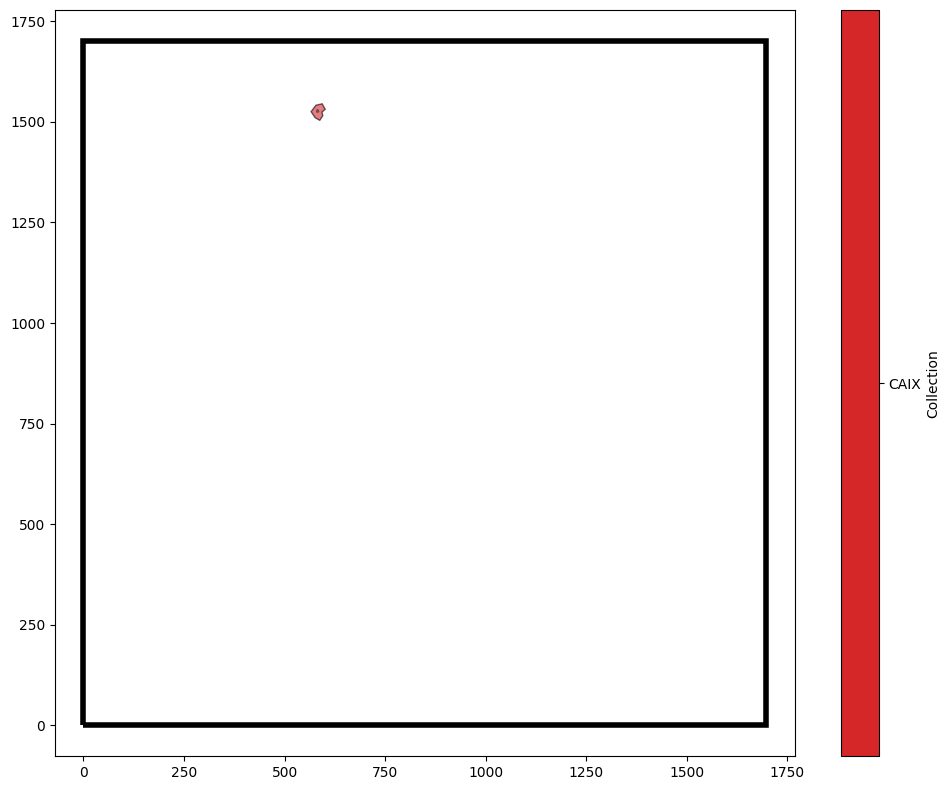

In [9]:
query_Pimo_containing_CAIX = ms.query.query(example_domain,('contains',( ('collection','CAIX'),('collection','Pimo') )),'is', True)

ms.visualise.visualise(example_domain,objects_to_plot=query_Pimo_containing_CAIX,show_boundary=True)

## Distance-based queries

Say we want to find all the cells within 50µm of an invasive edge of a tumour. MuSpan provides a way of quering the population based on distance.

Let us our Marcrophage data set to filter all Macrophages that are within 100µm of the epithelial region. 

The syntax for such a query is:

> `some_query = ms.query.query(domain, property, relation, comparison_value)`

Where the syntax for the property is:

> `property = ('distance', ('boundary', query_objects_1, query_objects_2))`

First we would build the two query objects. Are the objects Macrophages or PanCK?

In [11]:
# Queries identifing the cells of interest.
query_macrophage = ms.query.query(example_domain, ('collection', ), 
                                  'is', 'Macrophages')
query_tumour = ms.query.query(example_domain, ('collection',), 
                              'is', 'PanCK')

Now we can use the distance query to find all macrophages within 100 microns and further than 100 microns of the tumour cells.

In [13]:
# Within
query_mac_tumour_periphery_within_100 = ms.query.query(example_domain,
        ('distance', ('boundary', query_macrophage, query_tumour)),
          '<', 100)

# Outwith
query_mac_tumour_periphery_outside_100 = ms.query.query(example_domain,
        ('distance', ('boundary', query_macrophage, query_tumour)), 
        '>', 100)


Text(0.5, 1.0, 'Macros further than 100µm from Tumour boundary')

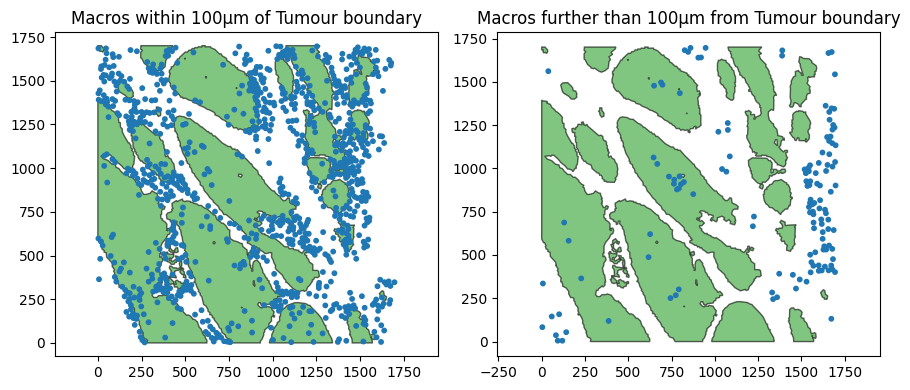

In [14]:
# plot the tumour and filtered macrophages together
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
fig.subplots_adjust(wspace=1.5)  # Increase the whitespace between the plots
ms.visualise.visualise(example_domain, 
    objects_to_plot=query_mac_tumour_periphery_within_100, 
    marker_size=10, ax=ax[0], add_cbar=False)
ms.visualise.visualise(example_domain, 
    objects_to_plot=query_tumour,ax=ax[0],add_cbar=False)
ax[0].set_title('Macros within 100µm of Tumour boundary')

ms.visualise.visualise(example_domain,
    objects_to_plot=query_mac_tumour_periphery_outside_100,
    marker_size=10,ax=ax[1],add_cbar=False)
ms.visualise.visualise(example_domain,
    objects_to_plot=query_tumour,ax=ax[1],add_cbar=False)
ax[1].set_title('Macros further than 100µm from Tumour boundary')

We can combine the distance (`'distance'`) query with a containment query (`'contains'`) to identify the macrophages that are infiltrating the tumour in a container (`query_container`).

In [15]:
# What macrophages are in the tumour region?
query_mac_in_tumour = ms.query.query(example_domain, 
    ('contains', (query_macrophage, query_tumour)), 
    'is', True)

# What macrophages are within 100 microns of tumour cells and also in the tumour region.
query_mac_infiltrated_periphery = ms.query.query_container(
    query_mac_tumour_periphery_within_100, 'AND', 
    query_mac_in_tumour, domain = example_domain)

Text(0.5, 1.0, 'Macros within 100µm of Tumour boundary (inside)')

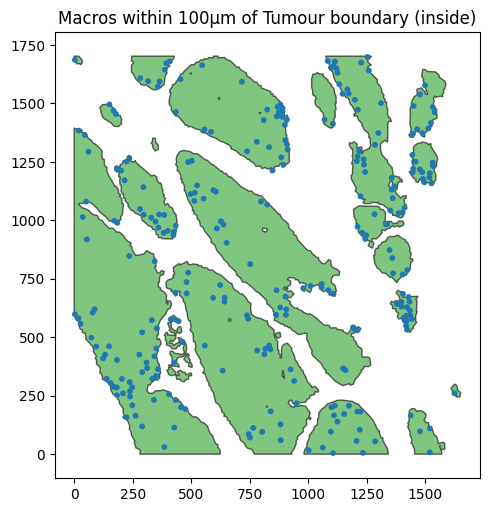

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ms.visualise.visualise(example_domain, objects_to_plot=query_mac_infiltrated_periphery, marker_size=10, ax=ax, add_cbar=False)
ms.visualise.visualise(example_domain,objects_to_plot=query_tumour,ax=ax,add_cbar=False)
ax.set_title('Macros within 100µm of Tumour boundary (inside)')